#feature scalling - standardization & Normalization

Feature Scaling is a data preprocessing technique used to normalize or standardize the range of independent variables (features) in your dataset so that all features contribute equally to the model performance.

Many machine learning algorithms (especially those based on distance or gradient) are sensitive to the scale of input features. For example:

📏 K-Nearest Neighbors (KNN)

🧠 Neural Networks

📉 Gradient Descent-based models (e.g., Linear/Logistic Regression, SVM)

🧮 Principal Component Analysis (PCA)

If features are on different scales, models may prioritize larger-magnitude features unfairly.

In [2]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

#Example:
#Consider two features: age (20–60) and salary (20,000–200,000).
#Without scaling, salary will dominate age due to its larger values.

data = np.array([[25, 50000],
                 [35, 100000],
                 [45, 150000]])

# Standardization (Z-score Normalization)



Output Range: No fixed range; data is centered around 0 with a standard deviation of 1

Use Case: Preferred when data follows a Gaussian (normal) distribution.

Example: Used in PCA, logistic regression, SVM, linear regression, etc.

In [3]:
# Standardization
standardized = StandardScaler().fit_transform(data)

print("Standardized:\n", standardized)



Standardized:
 [[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]


In [5]:
from sklearn.preprocessing import StandardScaler

# Assuming 'data' is already defined from a previous cell
# If not, you might need to define it, e.g.:
# data = np.array([[25, 50000],
#                  [35, 100000],
#                  [45, 150000]])

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the data and transform it
standardized_data_new = scaler.fit_transform(data)

print("Original data:\n", data)
print("\nStandardized data (using StandardScaler):\n", standardized_data_new)

Original data:
 [[    25  50000]
 [    35 100000]
 [    45 150000]]

Standardized data (using StandardScaler):
 [[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]


#Normalization (Min-Max Scaling)

Output Range: Scales values to a [0, 1] range (or any custom range)

Use Case: Preferred when the distribution is not normal or when using algorithms that are sensitive to the magnitude of data, like:

KNN, neural networks, distance-based models

In [4]:
# Normalization
normalized = MinMaxScaler().fit_transform(data)
print("Normalized:\n", normalized)

Normalized:
 [[0.  0. ]
 [0.5 0.5]
 [1.  1. ]]


In [6]:
from sklearn.preprocessing import MinMaxScaler

# Assuming 'data' is already defined from a previous cell
# If not, you might need to define it, e.g.:
# data = np.array([[25, 50000],
#                  [35, 100000],
#                  [45, 150000]])

# Initialize the MinMaxScaler
min_max_scaler = MinMaxScaler()

# Fit the scaler to the data and transform it
normalized_data_new = min_max_scaler.fit_transform(data)

print("Original data:\n", data)
print("\nNormalized data (using MinMaxScaler):\n", normalized_data_new)

Original data:
 [[    25  50000]
 [    35 100000]
 [    45 150000]]

Normalized data (using MinMaxScaler):
 [[0.  0. ]
 [0.5 0.5]
 [1.  1. ]]


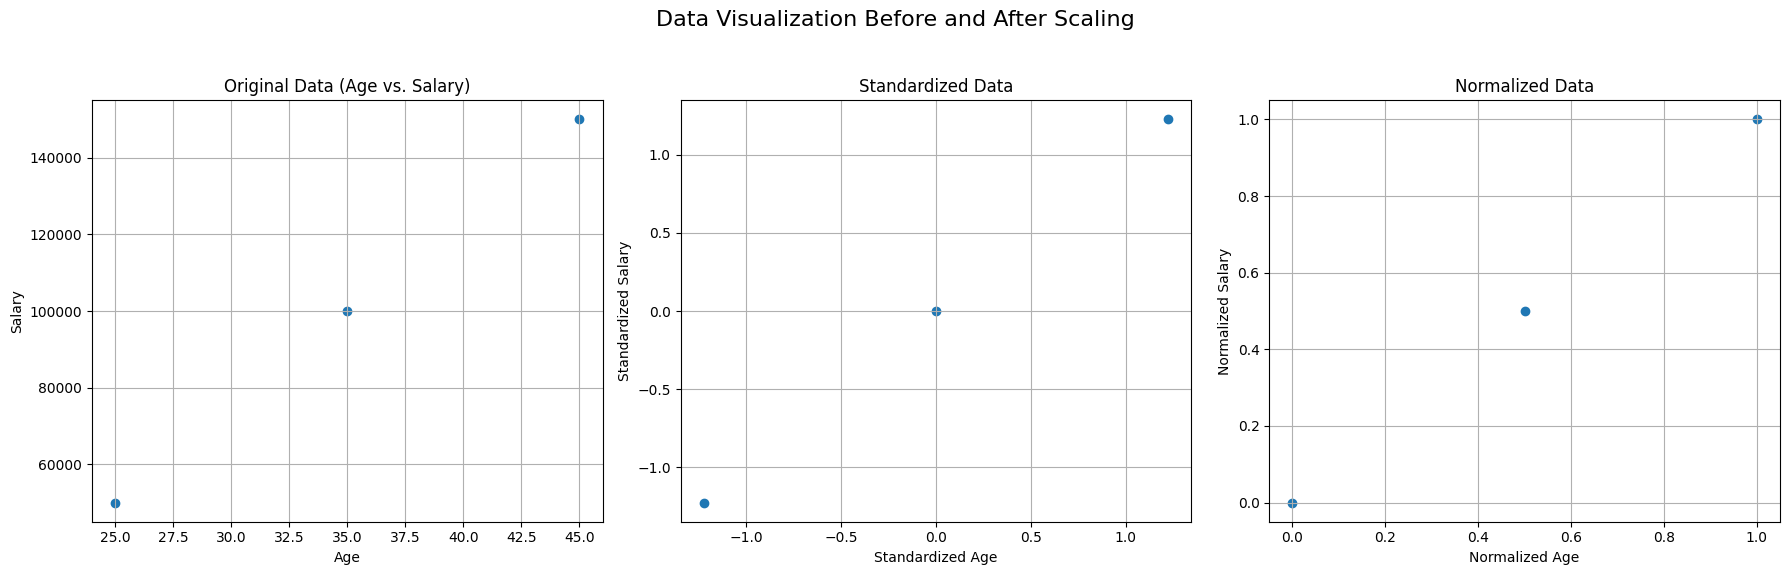

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Data Visualization Before and After Scaling', fontsize=16)

# Plot Original Data
axes[0].scatter(data[:, 0], data[:, 1])
axes[0].set_title('Original Data (Age vs. Salary)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Salary')
axes[0].grid(True)

# Plot Standardized Data
axes[1].scatter(standardized_data_new[:, 0], standardized_data_new[:, 1])
axes[1].set_title('Standardized Data')
axes[1].set_xlabel('Standardized Age')
axes[1].set_ylabel('Standardized Salary')
axes[1].grid(True)

# Plot Normalized Data
axes[2].scatter(normalized_data_new[:, 0], normalized_data_new[:, 1])
axes[2].set_title('Normalized Data')
axes[2].set_xlabel('Normalized Age')
axes[2].set_ylabel('Normalized Salary')
axes[2].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

#🔸 Summary Table:

| Aspect                | Standardization           | Normalization             |
| --------------------- | ------------------------- | ------------------------- |
| Formula               | $(x - \mu)/\sigma$        | $(x - min) / (max - min)$ |
| Output Range          | No fixed range (mean=0)   | Typically \[0, 1]         |
| Sensitive to Outliers | Less                      | More                      |
| Best For              | Normally distributed data | Distance-based algorithms |


#extra:
Use Standardization when you assume normal distribution.

Use Normalization when using distance-based algorithms or bounded inputs (e.g., NN activation functions like sigmoid).

## Resources
* Use Standardization when you assume normal distribution.
* Use Normalization when using distance-based algorithms or bounded inputs (e.g., NN activation functions like sigmoid).

The decision to use Standardization or Normalization largely depends on your data's distribution and the machine learning algorithm you plan to use. Here's a summary of when to choose which, based on the information in your notebook:

**Standardization (Z-score Normalization):**

When to use: It's generally preferred when your data follows a Gaussian (normal) distribution. Many algorithms assume a normal distribution for optimal performance.
Algorithms that benefit: Often used with algorithms like PCA, Linear Regression, Logistic Regression, and Support Vector Machines (SVMs).
Output: It centers the data around a mean of 0 with a standard deviation of 1, but it does not bound the output to a specific range.
Outliers: It is less sensitive to outliers compared to normalization.

**Normalization (Min-Max Scaling):**

When to use: Preferred when the distribution of your data is not normal, or when you are using algorithms that are sensitive to the magnitude of data or require inputs within a specific bounded range.
Algorithms that benefit: Ideal for distance-based algorithms like K-Nearest Neighbors (KNN), and algorithms that use activation functions requiring bounded inputs, such as Neural Networks (especially with sigmoid or tanh activation functions).
Output: It scales values to a specific range, typically [0, 1].
Outliers: It is more sensitive to outliers because it scales values relative to the minimum and maximum, so extreme values can compress the range of other data points.

### Applying Scalers to a Real Dataset: California Housing

In [9]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Load a real dataset from sample_data
california_df = pd.read_csv('/content/sample_data/california_housing_train.csv')

print("Original California Housing Data (first 5 rows):")
display(california_df.head())


Original California Housing Data (first 5 rows):


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


Let's select a few numerical columns for scaling: `housing_median_age`, `total_rooms`, `population`, and `median_income`.

In [10]:
features_to_scale = ['housing_median_age', 'total_rooms', 'population', 'median_income']
data_for_scaling = california_df[features_to_scale]

# --- Standardization ---
scaler_standard = StandardScaler()
standardized_data = scaler_standard.fit_transform(data_for_scaling)

# Convert back to DataFrame for better readability
standardized_df = pd.DataFrame(standardized_data, columns=features_to_scale)

print("\nStandardized Data (first 5 rows):")
display(standardized_df.head())



Standardized Data (first 5 rows):


,housing_median_age,total_rooms,population,median_income
0,-1.079671,1.361695,-0.361184,-1.252543
1,-0.761872,2.296608,-0.261865,-1.081483
2,-0.920772,-0.882462,-0.955354,-1.170105
3,-1.159121,-0.524186,-0.796793,-0.362600
4,-0.682422,-0.545747,-0.701830,-1.026454


In [11]:
# --- Normalization ---
scaler_minmax = MinMaxScaler()
normalized_data = scaler_minmax.fit_transform(data_for_scaling)

# Convert back to DataFrame for better readability
normalized_df = pd.DataFrame(normalized_data, columns=features_to_scale)

print("\nNormalized Data (first 5 rows):")
display(normalized_df.head())



Normalized Data (first 5 rows):


,housing_median_age,total_rooms,population,median_income
0,0.274510,0.147885,0.028364,0.068530
1,0.352941,0.201608,0.031559,0.091040
2,0.313725,0.018927,0.009249,0.079378
3,0.254902,0.039515,0.014350,0.185639
4,0.372549,0.038276,0.017405,0.098281


As you can see, the `StandardScaler` transforms the data to have a mean of 0 and a standard deviation of 1, while `MinMaxScaler` scales the data to a range between 0 and 1.

### Visualizing Feature Distributions Before and After Scaling

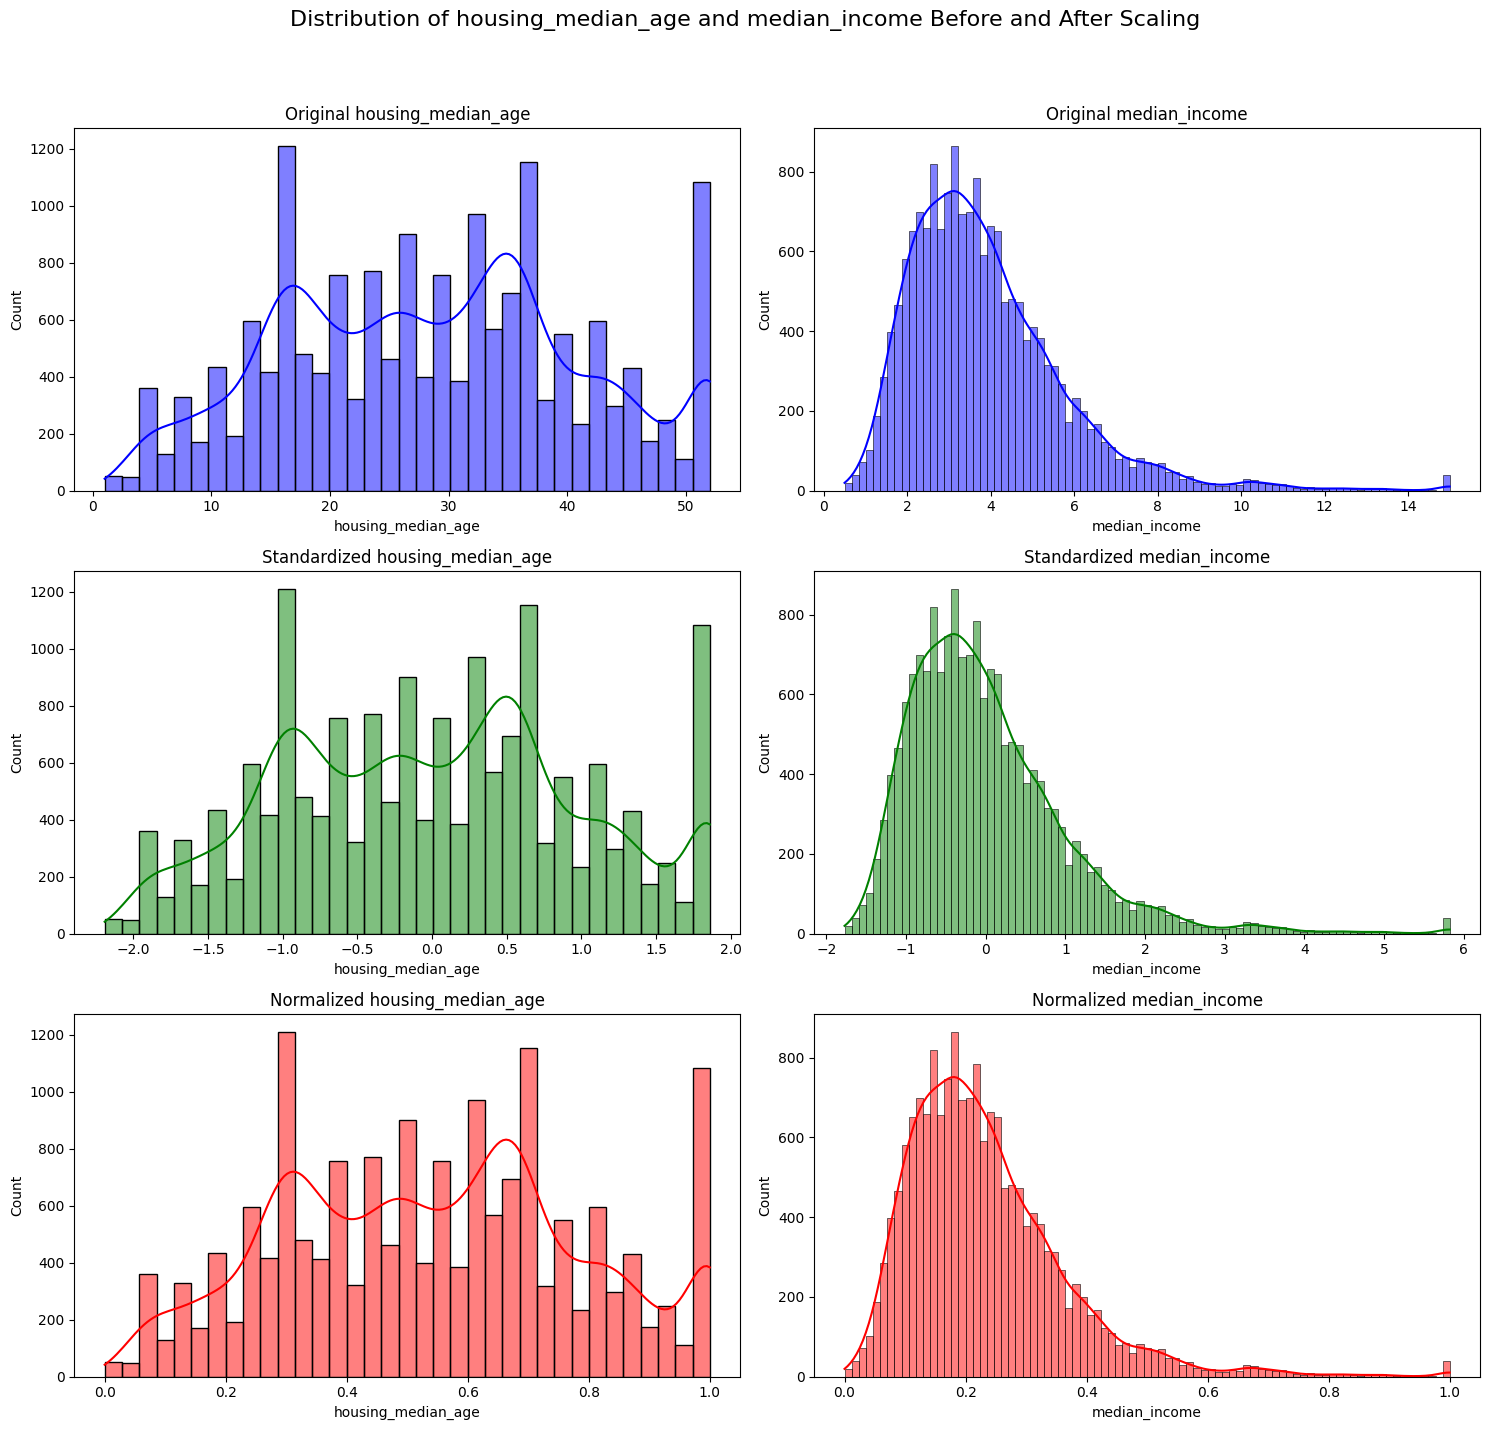

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select a couple of features to visualize their distributions
feature1 = 'housing_median_age'
feature2 = 'median_income'

# Create a figure and a set of subplots for each feature
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle(f'Distribution of {feature1} and {feature2} Before and After Scaling', fontsize=16)

# --- Original Data Distributions ---
sns.histplot(data_for_scaling[feature1], kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title(f'Original {feature1}')
sns.histplot(data_for_scaling[feature2], kde=True, ax=axes[0, 1], color='blue')
axes[0, 1].set_title(f'Original {feature2}')

# --- Standardized Data Distributions ---
sns.histplot(standardized_df[feature1], kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title(f'Standardized {feature1}')
sns.histplot(standardized_df[feature2], kde=True, ax=axes[1, 1], color='green')
axes[1, 1].set_title(f'Standardized {feature2}')

# --- Normalized Data Distributions ---
sns.histplot(normalized_df[feature1], kde=True, ax=axes[2, 0], color='red')
axes[2, 0].set_title(f'Normalized {feature1}')
sns.histplot(normalized_df[feature2], kde=True, ax=axes[2, 1], color='red')
axes[2, 1].set_title(f'Normalized {feature2}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


As you can observe from the plots:

*   **Original Data:** The features have their original range and distributions.
*   **Standardized Data:** The distribution shape is preserved, but the x-axis values are transformed to be centered around zero, with most values typically between -3 and 3.
*   **Normalized Data:** The distribution shape is also preserved, but the x-axis values are squeezed into the [0, 1] range.